# Feature-Engineering Comparison — XGBoost only

Tests whether preprocessing/feature engineering can beat the raw-sensor baseline
(`run_03_R0605-PA_L60_H30`, XGBoost: MAE 0.0114, RMSE 0.0151, MAPE 2.34%, R2 0.3812)
on rack R0605-PA, lookback=60/horizon=30.

Only XGBoost is trained (fastest model) so several variants can be compared quickly.
TH sensor aggregation/delta features account for BOTH temperature and humidity
fields, not temperature alone. This is exploratory — feature-engineering functions
live here, not in `rack_forecast/`, until one is proven worth promoting.


## 0. Setup

In [1]:
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler

from rack_forecast import ExperimentConfig
from rack_forecast.data import build_dataset
from rack_forecast.pipeline import prepare_data, PreparedData
from rack_forecast.windowing import make_supervised
from rack_forecast.trainer import build_and_train, DEVICE
from rack_forecast.evaluate import evaluate, compute_metrics

from scipy.signal import savgol_filter

print('Device:', DEVICE)

[rack_forecast] device: cuda
Device: cuda


## 1. Config & base dataset

`train_days=60` clips training to the first 60 days so ~6 variants can be trained
quickly. EVERY variant below uses this same `cfg` (and the `data` built from it) —
no variant gets a different config, so the comparison is apples-to-apples. This
trades exact reproducibility of the full-data `run_03` numbers for iteration speed;
treat this notebook's `baseline` as the reference point for every other variant
here, not `run_03` directly.

In [2]:
cfg = ExperimentConfig(
    target_rack='R0605-PA',
    lookback=60,
    horizon=30,
    models=['xgboost'],
    fast_mode=True,
    train_days=60,
    predict_days=None,
    run_id='feature_eda',
)
print(cfg)

data = build_dataset(cfg)
target = cfg.target_col
print('Base dataset:', data.shape, data.index.min(), '->', data.index.max())
data.head()

ExperimentConfig(target_rack='R0605-PA', resample='30s', lookback=60, horizon=30, models=['xgboost'], dl_epochs=30, fast_mode=True, train_days=60, predict_days=None, run_id='feature_eda')
Base dataset: (521246, 17) 2022-09-01 00:00:00 -> 2023-02-28 23:59:30


,R0605-PA__kW,R0605-PA__V,R0605-PA__A,R0605-PA__PF,R0605-PA__Hz,THFT__temp_C,THFT__humidity_pct,THFM__temp_C,THFM__humidity_pct,THFB__temp_C,THFB__humidity_pct,THBB__temp_C,THBB__humidity_pct,THBM__temp_C,THBM__humidity_pct,THBT__temp_C,THBT__humidity_pct
timestamp,,,,,,,,,,,,,,,,,
2022-09-01 00:00:00,0.563,229.4,2.79,0.88,659.8,33.3,44.0,33.3,46.0,33.9,43.0,38.1,35.0,34.6,42.0,36.9,38.0
2022-09-01 00:00:30,0.514,229.1,2.57,0.87,659.8,33.3,44.0,33.3,46.0,33.8,43.0,38.1,35.0,34.6,42.0,37.0,38.0
2022-09-01 00:01:00,0.535,229.7,2.66,0.88,659.8,33.3,44.0,33.3,46.0,33.8,43.0,38.1,35.0,34.6,42.0,37.0,37.0
2022-09-01 00:01:30,0.511,229.7,2.56,0.87,659.8,33.3,44.0,33.3,46.0,33.8,43.0,38.1,35.0,34.6,42.0,37.1,37.0
2022-09-01 00:02:00,0.535,229.1,2.65,0.88,659.8,33.3,44.0,33.3,46.0,33.8,43.0,38.1,35.0,34.6,42.0,37.1,37.0


## 2. EDA — which features are actually worth testing?

Only kept here: computations that actually gate which variants get built/run in
Section 5 (`test_calendar`, `test_rolling`), plus the TH sensor column-group
definitions Section 3's feature builders need. Purely-illustrative analysis
(correlation heatmaps, redundancy/delta correlation checks) was removed since it
didn't feed into any variant decision — `th_aggregated`/`th_aggregated_deltaT`/
`delta_only` are tested unconditionally regardless of what those checks would have
shown.

### 2a. TH sensor column groups (needed by Section 3's feature builders)

In [3]:
# Front = THFT/THFM/THFB (top/mid/bottom intake), Back = THBB/THBM/THBT
# (bottom/mid/top exhaust) -- grouped by physical position (front vs back of the
# rack), not by which PDU (PA/PB) happens to report the reading in the CSV.
# Each sensor reports BOTH temp_C and humidity_pct -- account for both fields.
th_front_temp = ['THFT__temp_C', 'THFM__temp_C', 'THFB__temp_C']
th_back_temp = ['THBB__temp_C', 'THBM__temp_C', 'THBT__temp_C']
th_front_humi = ['THFT__humidity_pct', 'THFM__humidity_pct', 'THFB__humidity_pct']
th_back_humi = ['THBB__humidity_pct', 'THBM__humidity_pct', 'THBT__humidity_pct']
th_front = th_front_temp + th_front_humi
th_back = th_back_temp + th_back_humi

### 2b. Diurnal / weekly load pattern

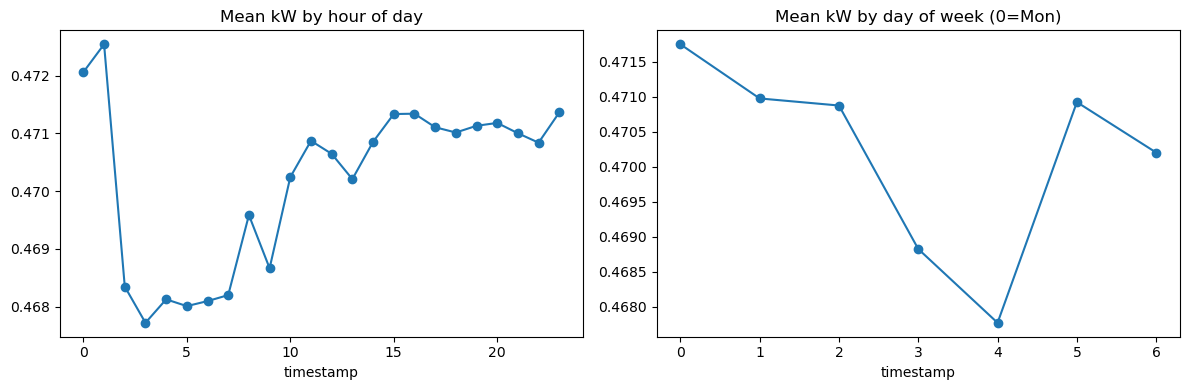

Diurnal signal strength (hourly range / target std): 0.180
Verdict: promising -> test calendar features


In [4]:
hourly = data.groupby(data.index.hour)[target].mean()
dow = data.groupby(data.index.dayofweek)[target].mean()

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
hourly.plot(ax=axes[0], marker='o', title='Mean kW by hour of day')
dow.plot(ax=axes[1], marker='o', title='Mean kW by day of week (0=Mon)')
plt.tight_layout()
plt.show()

diurnal_strength = (hourly.max() - hourly.min()) / data[target].std()
print(f'Diurnal signal strength (hourly range / target std): {diurnal_strength:.3f}')
test_calendar = diurnal_strength > 0.1
print('Verdict:', 'promising -> test calendar features' if test_calendar
      else 'weak diurnal pattern -> calendar features unlikely to help')

### 2c. Autocorrelation of target power (is recent history predictive?)

In [5]:
lags = [1, 2, 5, 10, 30, 60, 120, 360]
acf_vals = {lag: data[target].autocorr(lag) for lag in lags}
for lag, v in acf_vals.items():
    print(f'  lag={lag:>4} steps ({lag * 30 / 60:5.1f} min): acf={v:.4f}')

test_rolling = acf_vals[1] > 0.5
print('Verdict:', 'high short-lag persistence -> rolling stats likely useful' if test_rolling
      else 'low persistence -> rolling stats unlikely to add much')

  lag=   1 steps (  0.5 min): acf=0.0347
  lag=   2 steps (  1.0 min): acf=0.6781
  lag=   5 steps (  2.5 min): acf=0.0312
  lag=  10 steps (  5.0 min): acf=0.7272
  lag=  30 steps ( 15.0 min): acf=0.7236
  lag=  60 steps ( 30.0 min): acf=0.7203
  lag= 120 steps ( 60.0 min): acf=0.7143
  lag= 360 steps (180.0 min): acf=0.6963
Verdict: low persistence -> rolling stats unlikely to add much


## 3. Feature-builder functions

Each takes the base `data` DataFrame and returns an augmented copy. Applied to the
FULL DataFrame before `prepare_data()`'s train/test split — safe from leakage since
rolling/lag features only look backward in time.

In [6]:
def add_th_aggregates(data):
    """Replace the 12 raw TH temp+humidity columns with front/back means for
    EACH field (temp and humidity), 4 aggregated columns total."""
    d = data.copy()
    d['TH_front_mean_temp'] = d[th_front_temp].mean(axis=1)
    d['TH_back_mean_temp'] = d[th_back_temp].mean(axis=1)
    d['TH_front_mean_humi'] = d[th_front_humi].mean(axis=1)
    d['TH_back_mean_humi'] = d[th_back_humi].mean(axis=1)
    return d.drop(columns=th_front + th_back)


def add_delta_t(data):
    """Front-back delta-T AND delta-humidity on top of the TH aggregates."""
    d = add_th_aggregates(data)
    d['delta_T'] = d['TH_back_mean_temp'] - d['TH_front_mean_temp']
    d['delta_H'] = d['TH_back_mean_humi'] - d['TH_front_mean_humi']
    return d


def add_delta_only(data):
    """Drop ALL 12 raw TH columns (no aggregates either) and keep ONLY the 5 PM
    columns plus delta-T and delta-humidity -- 7 features total. Tests whether the
    deltas alone carry the useful signal, with nothing else from the TH sensors."""
    delta_t = data[th_back_temp].mean(axis=1) - data[th_front_temp].mean(axis=1)
    delta_h = data[th_back_humi].mean(axis=1) - data[th_front_humi].mean(axis=1)
    d = data.drop(columns=th_front + th_back)
    d['delta_T'] = delta_t
    d['delta_H'] = delta_h
    return d


def add_target_rolling(data, window=20):
    d = data.copy()
    d[f'{target}_roll_mean{window}'] = d[target].rolling(window).mean()
    d[f'{target}_roll_std{window}'] = d[target].rolling(window).std()
    return d


def add_calendar_features(data):
    d = data.copy()
    hour = d.index.hour + d.index.minute / 60
    d['hour_sin'] = np.sin(2 * np.pi * hour / 24)
    d['hour_cos'] = np.cos(2 * np.pi * hour / 24)
    d['dow_sin'] = np.sin(2 * np.pi * d.index.dayofweek / 7)
    d['dow_cos'] = np.cos(2 * np.pi * d.index.dayofweek / 7)
    return d


def finalize(data, label=''):
    """Drop rows with NaN introduced by rolling/lag features."""
    before = len(data)
    d = data.dropna()
    after = len(d)
    print(f'[{label}] dropna: {before:,} -> {after:,} rows '
          f'({before - after:,} dropped, {100 * (before - after) / before:.2f}%)')
    return d


def prepare_data_minmax(data, cfg):
    """Same split/shape logic as rack_forecast.pipeline.prepare_data(), but scales
    with MinMaxScaler (0-1 range) instead of StandardScaler."""
    months = sorted(data.index.to_period('M').unique())
    train_df = data[data.index.to_period('M').isin(months[:-1])]
    test_df = data[data.index.to_period('M').isin(months[-1:])]

    if cfg.train_days is not None:
        cutoff = train_df.index.min() + pd.Timedelta(days=cfg.train_days)
        train_df = train_df[train_df.index < cutoff]
    if cfg.predict_days is not None:
        cutoff = test_df.index.min() + pd.Timedelta(days=cfg.predict_days)
        test_df = test_df[test_df.index < cutoff]

    target_col = cfg.target_col
    feature_cols = list(data.columns)

    scaler = MinMaxScaler()
    X_train = scaler.fit_transform(train_df[feature_cols]).astype('float32')
    X_test = scaler.transform(test_df[feature_cols]).astype('float32')
    y_train, y_test = X_train, X_test

    target_idx = feature_cols.index(target_col)
    return PreparedData(
        train_df=train_df, test_df=test_df, months=months,
        feature_cols=feature_cols, target_idx=target_idx, n_feat=X_train.shape[1],
        X_train=X_train, y_train=y_train, X_test=X_test, y_test=y_test, scaler=scaler,
    )

In [7]:
def plot_feature(data_variant, feature_col, n=500):
    d = data_variant.iloc[:n]
    fig, ax1 = plt.subplots(figsize=(14, 4))
    ax1.plot(d.index, d[target], color='steelblue')
    ax2 = ax1.twinx()
    ax2.plot(d.index, d[feature_col], color='red', alpha=0.9)
    plt.tight_layout()
    plt.show()

## 4. Experiment harness

In [8]:
results = []

def run_variant(name, data_variant, cfg_variant=None, prep_fn=prepare_data):
    c = cfg_variant or cfg
    model_name = c.models[0]
    t0 = time.time()
    d = finalize(data_variant, label=name)
    prep = prep_fn(d, c)
    X_3d, y_sup = make_supervised(prep.X_train, prep.y_train, c.lookback)
    model = build_and_train(model_name, X_3d, y_sup, c.lookback, prep.n_feat, dl_epochs=c.dl_epochs)
    preds, actuals = evaluate(model, prep.X_test, prep.y_test, c.lookback, c.horizon,
                               prep.target_idx, prep.scaler, prep.n_feat)
    metrics = compute_metrics(actuals, preds)
    elapsed = time.time() - t0
    row = {'variant': name, 'n_features': prep.n_feat, **metrics, 'seconds': round(elapsed, 1)}
    results.append(row)
    print(f"[{name}] MAE={metrics['MAE']:.4f}  RMSE={metrics['RMSE']:.4f}  "
          f"MAPE={metrics['MAPE(%)']:.2f}%  R2={metrics['R2']:.4f}  ({elapsed:.1f}s)")
    return row

## 5. Run variants

Every variant below uses the SAME `cfg`/`data` from Section 1 — no per-variant
config. Organized into: 5a baseline, 5b MinMax scaler, 5c current_freq_remove,
5d TH sensor handling, 5e central tendency/variability/calendar, 5f distribution
shape (skewness/kurtosis).

In [9]:
run_variant('baseline', data)

[baseline] dropna: 521,246 -> 521,246 rows (0 dropped, 0.00%)
    backend: cuda


  steps:   0%|          | 0/30 [00:00<?, ?step/s]c:\Users\quang\anaconda3\envs\ntu_cooling\Lib\site-packages\xgboost\core.py:751: UserWarning: [13:10:07] WARNING: C:\Users\task_177929407859648\croot\xgboost-split_1779294268734\work\src\common\error_msg.cc:62: Falling back to prediction using DMatrix due to mismatched devices. This might lead to higher memory usage and slower performance. XGBoost is running on: cuda:0, while the input data is on: cpu.
Potential solutions:
- Use a data structure that matches the device ordinal in the booster.
- Set the device for booster before call to inplace_predict.

This warning will only be shown once.

  return func(**kwargs)


[baseline] MAE=0.0121  RMSE=0.0159  MAPE=2.48%  R2=0.3128  (99.7s)


{'variant': 'baseline',
 'n_features': 17,
 'MAE': 0.012093101628124714,
 'RMSE': np.float64(0.01594214428260265),
 'MAPE(%)': np.float32(2.4767916),
 'R2': 0.31275731325149536,
 'seconds': 99.7}

### 5b. MinMax scaler instead of StandardScaler

Same `cfg`/`data` and raw features as `baseline` -- only the scaler changes (0-1
range instead of zero-mean/unit-variance). `prepare_data_minmax()` mirrors
`rack_forecast.pipeline.prepare_data()`'s split/shape logic exactly (see
Section 3), swapping only the scaler class.

In [10]:
run_variant('baseline_minmax_scaler', data, cfg, prep_fn=prepare_data_minmax)

[baseline_minmax_scaler] dropna: 521,246 -> 521,246 rows (0 dropped, 0.00%)
    backend: cuda


[baseline_minmax_scaler] MAE=0.0121  RMSE=0.0159  MAPE=2.48%  R2=0.3140  (102.7s)


{'variant': 'baseline_minmax_scaler',
 'n_features': 17,
 'MAE': 0.012083345092833042,
 'RMSE': np.float64(0.015928284763039573),
 'MAPE(%)': np.float32(2.4752011),
 'R2': 0.3139514923095703,
 'seconds': 102.7}

### 5c. `current_freq_remove`: drop `A` and `Hz`

Section 13 (feature-selection strategy): remove near-zero-variance and
highly-correlated-with-target raw PM columns. `Hz` (mains frequency) barely
moves; `A` (current) is expected to closely track `kW` (P ~ V*I at roughly
constant V/PF), making it a near-duplicate of the target rather than new
information.

In [11]:
def current_freq_remove(data):
    """Drop the raw R0605-PA__A and R0605-PA__Hz columns."""
    return data.drop(columns=[f'{cfg.target_rack}__A', f'{cfg.target_rack}__Hz'])

In [12]:
run_variant('current_freq_remove', current_freq_remove(data))

[current_freq_remove] dropna: 521,246 -> 521,246 rows (0 dropped, 0.00%)
    backend: cuda


[current_freq_remove] MAE=0.0124  RMSE=0.0161  MAPE=2.56%  R2=0.3003  (81.6s)


{'variant': 'current_freq_remove',
 'n_features': 15,
 'MAE': 0.012399004772305489,
 'RMSE': np.float64(0.016086374380597235),
 'MAPE(%)': np.float32(2.5599396),
 'R2': 0.300265908241272,
 'seconds': 81.6}

### 5d. TH sensor handling

`th_aggregated` / `th_aggregated_deltaT` / `delta_only` are always tested since
they're the core question (user's own hypothesis about TH sensor redundancy).

In [13]:
run_variant('th_aggregated', add_th_aggregates(data))
run_variant('th_aggregated_deltaT', add_delta_t(data))
run_variant('delta_only', add_delta_only(data))

[th_aggregated] dropna: 521,246 -> 521,246 rows (0 dropped, 0.00%)
    backend: cuda


[th_aggregated] MAE=0.0121  RMSE=0.0159  MAPE=2.48%  R2=0.3123  (37.6s)
[th_aggregated_deltaT] dropna: 521,246 -> 521,246 rows (0 dropped, 0.00%)
    backend: cuda


[th_aggregated_deltaT] MAE=0.0121  RMSE=0.0159  MAPE=2.48%  R2=0.3145  (51.2s)
[delta_only] dropna: 521,246 -> 521,246 rows (0 dropped, 0.00%)
    backend: cuda


[delta_only] MAE=0.0122  RMSE=0.0160  MAPE=2.48%  R2=0.3041  (23.4s)


{'variant': 'delta_only',
 'n_features': 7,
 'MAE': 0.012154461815953255,
 'RMSE': np.float64(0.016042406271816773),
 'MAPE(%)': np.float32(2.484644),
 'R2': 0.30408579111099243,
 'seconds': 23.4}

In [14]:
run_variant('delta_current_freq_remove', current_freq_remove(add_delta_only(data)))

[delta_current_freq_remove] dropna: 521,246 -> 521,246 rows (0 dropped, 0.00%)
    backend: cuda


[delta_current_freq_remove] MAE=0.0125  RMSE=0.0161  MAPE=2.58%  R2=0.2964  (13.7s)


{'variant': 'delta_current_freq_remove',
 'n_features': 5,
 'MAE': 0.012481048703193665,
 'RMSE': np.float64(0.016130796399174297),
 'MAPE(%)': np.float32(2.5793862),
 'R2': 0.29639601707458496,
 'seconds': 13.7}

### 5e. Central tendency, variability, calendar

`target_rolling_calendar` (gated behind the Section 2 EDA verdicts — only runs if
the diurnal or autocorrelation signal was promising) is the original combined
test; the rest are isolated variants (not combined) so each idea's effect can be
judged on its own:
- **Section 1 (central tendency)**: rolling mean + median of the target
- **Section 2 (variability)**: rolling std + IQR + peak-to-peak range
- **calendar_sincos**: hour/dow sin-cos only, no rolling stats mixed in
- **central_variability_calendar**: all three combined

All use `window=20` (10 min), matching the earlier `add_target_rolling` default.

In [15]:
# if test_calendar or test_rolling:
#     run_variant('target_rolling_calendar', add_calendar_features(add_target_rolling(data)))
# else:
#     print('Skipping target_rolling_calendar — Section 2 EDA did not support it '
#           '(weak diurnal pattern and low short-lag autocorrelation).')

In [16]:
def add_central_tendency(data, window=20):
    """Section 1 (central tendency): rolling mean + median of the target."""
    d = data.copy()
    d[f'{target}_roll_mean{window}'] = d[target].rolling(window).mean()
    d[f'{target}_roll_median{window}'] = d[target].rolling(window).median()
    return d


run_variant('central_tendency', add_central_tendency(data, 5))

[central_tendency] dropna: 521,246 -> 521,242 rows (4 dropped, 0.00%)
    backend: cuda


[central_tendency] MAE=0.0121  RMSE=0.0159  MAPE=2.47%  R2=0.3158  (127.3s)


{'variant': 'central_tendency',
 'n_features': 19,
 'MAE': 0.012074397876858711,
 'RMSE': np.float64(0.015907278449698546),
 'MAPE(%)': np.float32(2.472544),
 'R2': 0.31575995683670044,
 'seconds': 127.3}

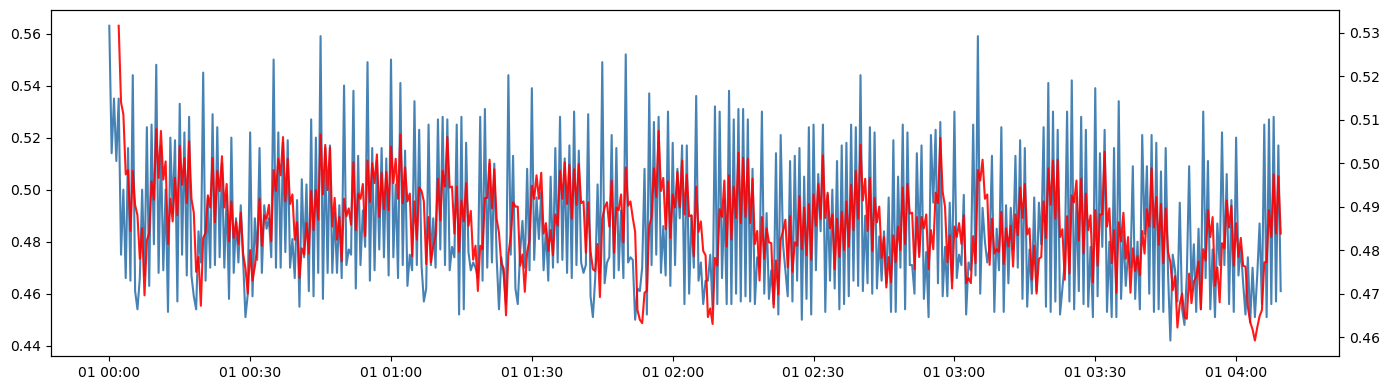

In [17]:
plot_feature(add_central_tendency(data, 5), f'{target}_roll_mean5')

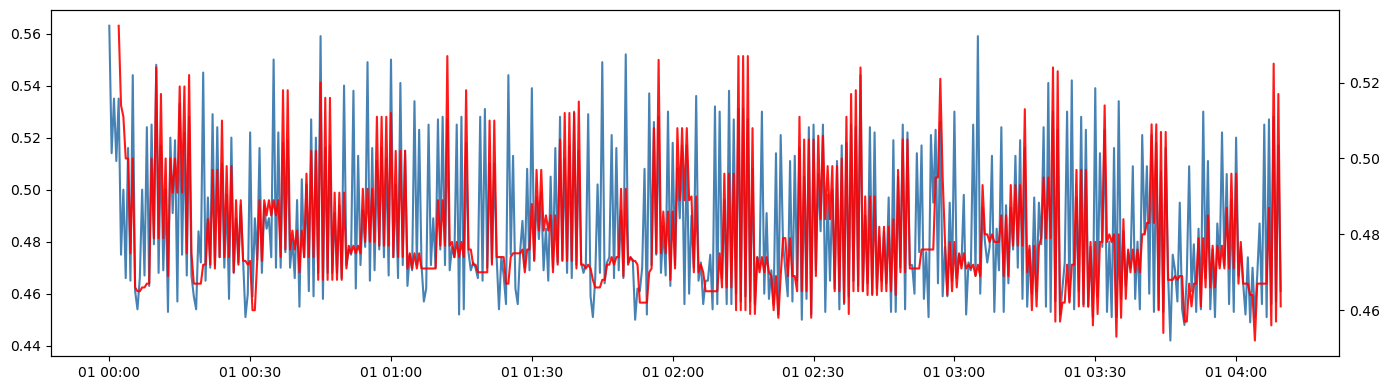

In [18]:
plot_feature(add_central_tendency(data, 5), f'{target}_roll_median5')

In [19]:
def add_variability(data, window=20):
    """Section 2 (variability): rolling std, IQR, and peak-to-peak range."""
    d = data.copy()
    roll = d[target].rolling(window)
    d[f'{target}_roll_std{window}'] = roll.std()
    d[f'{target}_roll_iqr{window}'] = roll.quantile(0.75) - roll.quantile(0.25)
    d[f'{target}_roll_ptp{window}'] = roll.max() - roll.min()
    return d


run_variant('variability', add_variability(data, 5))

[variability] dropna: 521,246 -> 521,242 rows (4 dropped, 0.00%)
    backend: cuda


[variability] MAE=0.0121  RMSE=0.0158  MAPE=2.48%  R2=0.3211  (137.5s)


{'variant': 'variability',
 'n_features': 20,
 'MAE': 0.012062466703355312,
 'RMSE': np.float64(0.01584563623735371),
 'MAPE(%)': np.float32(2.4770467),
 'R2': 0.3210526704788208,
 'seconds': 137.5}

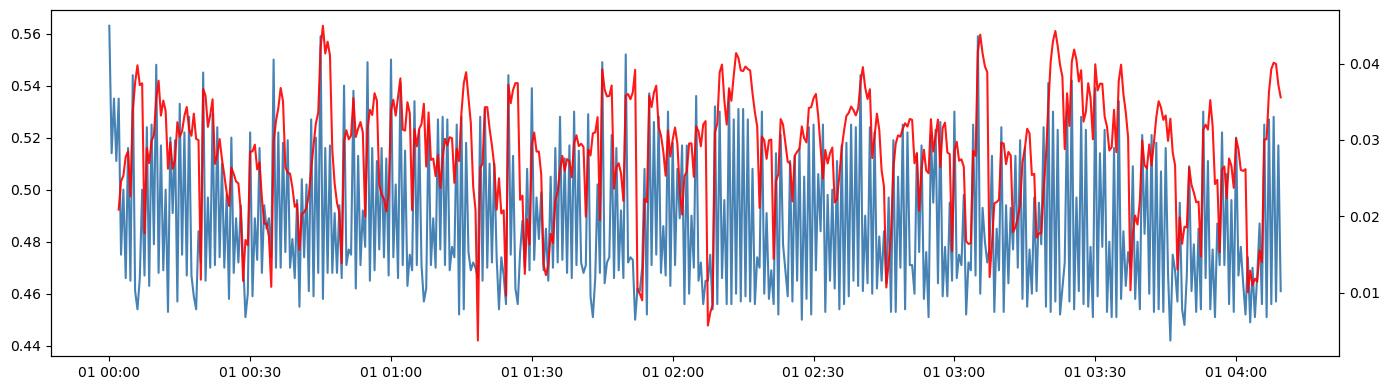

In [20]:
plot_feature(add_variability(data, 5), f'{target}_roll_std5')

In [21]:
# roll_calendar: reuses add_calendar_features() from Section 3 directly --
# hour/dow sin-cos only, no rolling stats mixed in (isolated from the earlier
# combined target_rolling_calendar test).
run_variant('roll_calendar', add_calendar_features(data))

[roll_calendar] dropna: 521,246 -> 521,246 rows (0 dropped, 0.00%)
    backend: cuda


[roll_calendar] MAE=0.0121  RMSE=0.0159  MAPE=2.47%  R2=0.3135  (145.9s)


{'variant': 'roll_calendar',
 'n_features': 21,
 'MAE': 0.01207824982702732,
 'RMSE': np.float64(0.015933074906602108),
 'MAPE(%)': np.float32(2.4732747),
 'R2': 0.3135390281677246,
 'seconds': 145.9}

In [22]:
# Combines all three isolated 5e variants: central tendency (mean+median) +
# variability (std+IQR+ptp) + calendar sin-cos, all in one variant.
run_variant('central_variability_calendar',
            add_calendar_features(add_variability(add_central_tendency(data, 5), 5)))

[central_variability_calendar] dropna: 521,246 -> 521,242 rows (4 dropped, 0.00%)
    backend: cuda


[central_variability_calendar] MAE=0.0120  RMSE=0.0157  MAPE=2.46%  R2=0.3318  (229.3s)


{'variant': 'central_variability_calendar',
 'n_features': 26,
 'MAE': 0.011969713494181633,
 'RMSE': np.float64(0.015719549578520967),
 'MAPE(%)': np.float32(2.4586575),
 'R2': 0.331814706325531,
 'seconds': 229.3}

### 5f. Distribution shape (Section 3): skewness + kurtosis

Uses `window=60` (30 min, = `cfg.lookback`) instead of the `window=20` used above
-- the professor's doc explicitly says kurtosis needs "windows containing at
least 30-60 observations" to be stable, so `window=20` would be inappropriate
here. `pandas.rolling().kurt()` already computes **excess** kurtosis (Fisher's
definition, normal distribution = 0), matching "Excess Kurtosis = Kurtosis - 3"
with no extra subtraction needed.

In [23]:
def add_skewness(data, window=60):
    d = data.copy()
    d[f'{target}_roll_skew{window}'] = d[target].rolling(window).skew()
    return d


run_variant('skewness', add_skewness(data))

[skewness] dropna: 521,246 -> 521,187 rows (59 dropped, 0.01%)
    backend: cuda


[skewness] MAE=0.0121  RMSE=0.0160  MAPE=2.48%  R2=0.3067  (117.9s)


{'variant': 'skewness',
 'n_features': 18,
 'MAE': 0.012131723575294018,
 'RMSE': np.float64(0.01601193719221878),
 'MAPE(%)': np.float32(2.4834082),
 'R2': 0.30672669410705566,
 'seconds': 117.9}

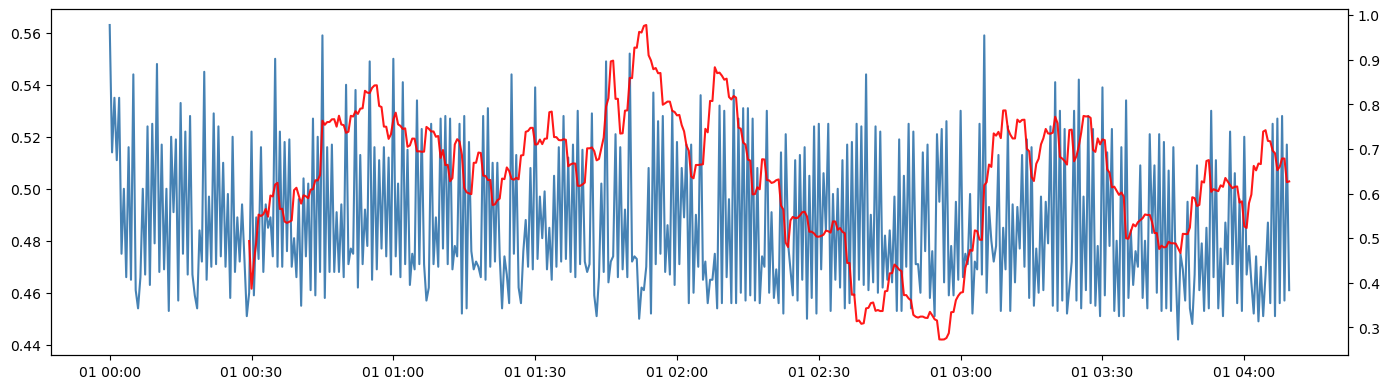

In [24]:
plot_feature(add_skewness(data), f'{target}_roll_skew60')

In [25]:
def add_kurtosis(data, window=60):
    d = data.copy()
    d[f'{target}_roll_kurt{window}'] = d[target].rolling(window).kurt()
    return d


run_variant('kurtosis', add_kurtosis(data))

[kurtosis] dropna: 521,246 -> 521,187 rows (59 dropped, 0.01%)
    backend: cuda


[kurtosis] MAE=0.0120  RMSE=0.0159  MAPE=2.47%  R2=0.3188  (118.7s)


{'variant': 'kurtosis',
 'n_features': 18,
 'MAE': 0.012038614600896835,
 'RMSE': np.float64(0.015872182004426815),
 'MAPE(%)': np.float32(2.4680142),
 'R2': 0.31877589225769043,
 'seconds': 118.7}

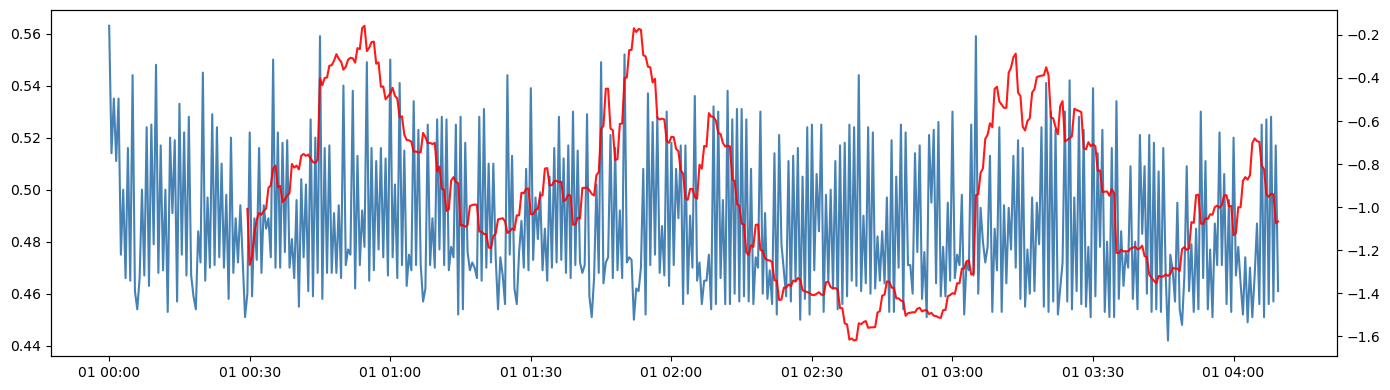

In [26]:
plot_feature(add_kurtosis(data, 60), f'{target}_roll_kurt60')

In [27]:
# Combines skewness + kurtosis in one variant.
run_variant('skew_kurtosis', add_kurtosis(add_skewness(data)))

[skew_kurtosis] dropna: 521,246 -> 521,187 rows (59 dropped, 0.01%)
    backend: cuda


[skew_kurtosis] MAE=0.0122  RMSE=0.0162  MAPE=2.50%  R2=0.2916  (127.4s)


{'variant': 'skew_kurtosis',
 'n_features': 19,
 'MAE': 0.012236303649842739,
 'RMSE': np.float64(0.01618550920976915),
 'MAPE(%)': np.float32(2.5022805),
 'R2': 0.2916147708892822,
 'seconds': 127.4}

### 5g. First derivative / rate-of-change (Section 4)

Uses a **backward** difference, not the doc's literal central difference
(`x[t+1]-x[t-1]`) -- that formula uses a FUTURE value relative to row `t`, which
would leak the model's own prediction target into a feature for the last row of
every lookback window. `(x[t] - x[t-2]) / 60` keeps the same ~1-minute spacing
(2 steps x 30s) while staying fully causal, consistent with every other feature
in this notebook.

Smoothed with a SHORT rolling median (`window=5`, 2.5 min) before differencing --
much shorter than the `window=20`/`window=60` used elsewhere, since over-smoothing
here would flatten out the transient signal a derivative is meant to capture.

In [28]:
def add_derivative(data, smooth_window=5):
    """Section 4: instantaneous rate-of-change of the target, kW/min.
    Backward difference (not the doc's central difference) to stay causal --
    see markdown above."""
    d = data.copy()
    smoothed = d[target].rolling(smooth_window, min_periods=1).median()
    d[f'{target}_deriv'] = smoothed - smoothed.shift(2)   # (x[t]-x[t-2]) -- already kW/min, 2*30s=60s
    return d


run_variant('derivative', add_derivative(data))

[derivative] dropna: 521,246 -> 521,244 rows (2 dropped, 0.00%)
    backend: cuda


[derivative] MAE=0.0121  RMSE=0.0160  MAPE=2.48%  R2=0.3105  (117.8s)


{'variant': 'derivative',
 'n_features': 18,
 'MAE': 0.012111283838748932,
 'RMSE': np.float64(0.01596782517694538),
 'MAPE(%)': np.float32(2.4799087),
 'R2': 0.31054139137268066,
 'seconds': 117.8}

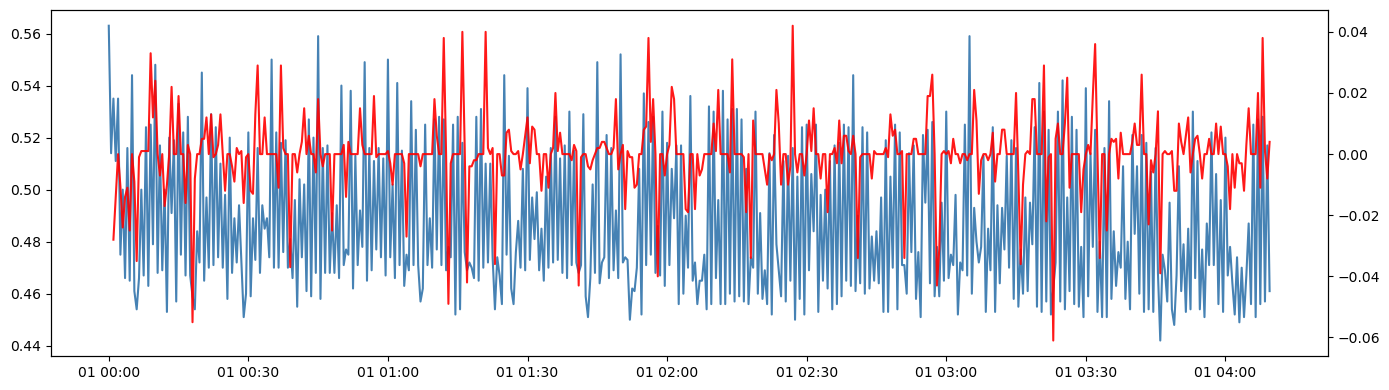

In [29]:
plot_feature(add_derivative(data), f'{target}_deriv')

In [30]:
def add_derivative_stats(data, smooth_window=5, window=20):
    """Rolling stats of the derivative signal: mean, std, max positive, max negative."""
    d = add_derivative(data, smooth_window)
    deriv = d[f'{target}_deriv']
    roll = deriv.rolling(window)
    d[f'{target}_deriv_mean{window}'] = roll.mean()
    d[f'{target}_deriv_std{window}'] = roll.std()
    d[f'{target}_deriv_maxpos{window}'] = roll.apply(lambda x: x[x > 0].max() if (x > 0).any() else 0)
    d[f'{target}_deriv_maxneg{window}'] = roll.apply(lambda x: x[x < 0].min() if (x < 0).any() else 0)
    return d


run_variant('derivative_stats', add_derivative_stats(data))

[derivative_stats] dropna: 521,246 -> 521,225 rows (21 dropped, 0.00%)
    backend: cuda


[derivative_stats] MAE=0.0121  RMSE=0.0159  MAPE=2.48%  R2=0.3135  (154.5s)


{'variant': 'derivative_stats',
 'n_features': 22,
 'MAE': 0.012093575671315193,
 'RMSE': np.float64(0.0159332895341656),
 'MAPE(%)': np.float32(2.4772894),
 'R2': 0.3135204315185547,
 'seconds': 154.5}

### 5h. Smoothing filters as features — Savitzky-Golay + EMA

Smoothed versions of the target itself (not the derivative), same idea as
`add_central_tendency`'s rolling mean/median but using two different filter types.

`savgol_filter` uses a CENTERED window by default (looks both backward and
forward), which would leak future values into the feature. Made causal by
shifting the filtered output forward by half the window length, so the value
reported "at time t" only reflects data up to t.

EWMA (`pandas.ewm()`) is naturally causal already -- no shift needed.

MA (rolling mean/median), EMA, and Savitzky-Golay are all low-pass filters
(attenuate fast fluctuations, preserve slow trend) -- no separate "low-pass
filter" entry needed on top of these.

In [31]:
def add_savgol_filter(data, window_length=11, polyorder=2):
    """Savitzky-Golay smoothed target, made causal via a forward shift."""
    d = data.copy()
    shift = (window_length - 1) // 2
    smoothed = savgol_filter(d[target].values, window_length, polyorder)
    d[f'{target}_savgol_smooth'] = pd.Series(smoothed, index=d.index).shift(shift)
    return d


run_variant('savgol_filter', add_savgol_filter(data))

[savgol_filter] dropna: 521,246 -> 521,241 rows (5 dropped, 0.00%)
    backend: cuda


[savgol_filter] MAE=0.0121  RMSE=0.0160  MAPE=2.48%  R2=0.3115  (110.5s)


{'variant': 'savgol_filter',
 'n_features': 18,
 'MAE': 0.012098351493477821,
 'RMSE': np.float64(0.015957228392056738),
 'MAPE(%)': np.float32(2.4767618),
 'R2': 0.31145620346069336,
 'seconds': 110.5}

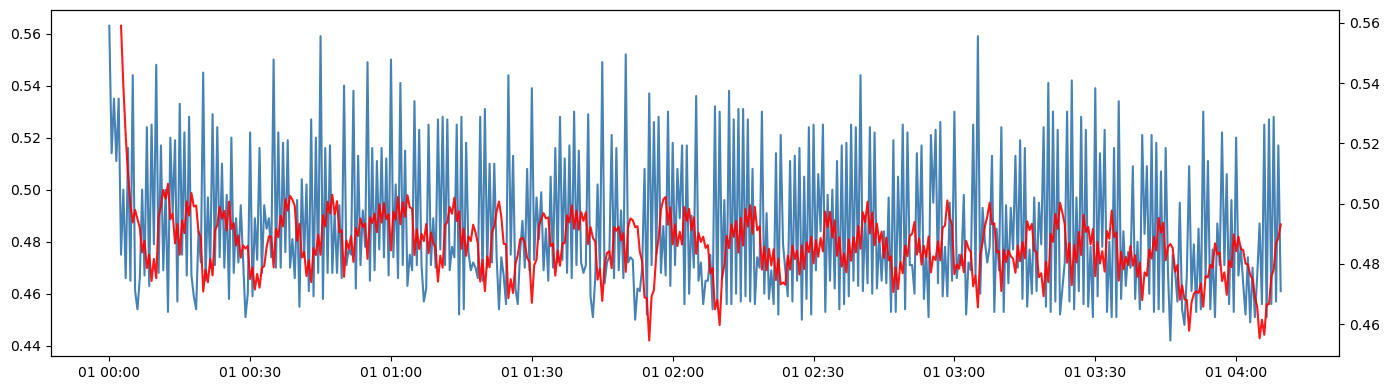

In [32]:
plot_feature(add_savgol_filter(data), f'{target}_savgol_smooth')

In [33]:
def add_ema_filter(data, span=5):
    """EWMA smoothed target -- already causal, no shift needed."""
    d = data.copy()
    d[f'{target}_ema_smooth'] = d[target].ewm(span=span, adjust=False).mean()
    return d


run_variant('ema_filter', add_ema_filter(data))

[ema_filter] dropna: 521,246 -> 521,246 rows (0 dropped, 0.00%)
    backend: cuda


[ema_filter] MAE=0.0122  RMSE=0.0161  MAPE=2.49%  R2=0.3027  (109.7s)


{'variant': 'ema_filter',
 'n_features': 18,
 'MAE': 0.012179402634501457,
 'RMSE': np.float64(0.016058597831011052),
 'MAPE(%)': np.float32(2.4926848),
 'R2': 0.3026803731918335,
 'seconds': 109.7}

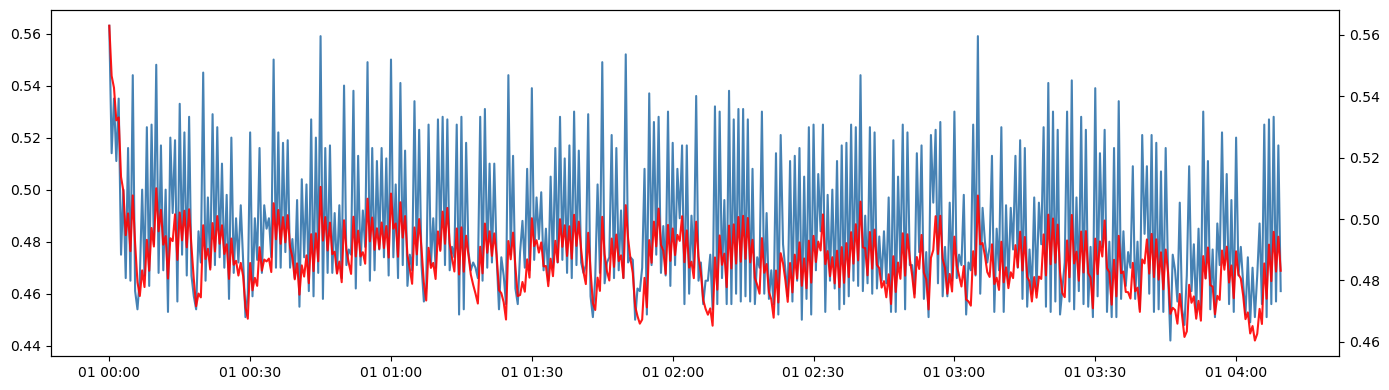

In [34]:
plot_feature(add_ema_filter(data), f'{target}_ema_smooth')

### 5i. Trend features (Section 6): slope + R², half-window ratio, EMA-diff

All three are causal by construction -- `rolling(window)` only ever looks at
the current + past `window` values, no centering/shift needed (unlike the
Savitzky-Golay filter earlier).

In [35]:
def add_trend_slope(data, window=20):
    """Rolling linear regression slope + R^2 of the target over the window."""
    d = data.copy()
    x = np.arange(window)

    def _slope(y):
        if np.all(y == y[0]):
            return 0.0
        return np.polyfit(x, y, 1)[0]

    def _r2(y):
        if np.all(y == y[0]):
            return 0.0
        coeffs = np.polyfit(x, y, 1)
        y_pred = np.polyval(coeffs, x)
        ss_res = np.sum((y - y_pred) ** 2)
        ss_tot = np.sum((y - y.mean()) ** 2)
        return 1 - ss_res / ss_tot if ss_tot > 0 else 0.0

    d[f'{target}_trend_slope{window}'] = d[target].rolling(window).apply(_slope, raw=True)
    d[f'{target}_trend_r2{window}'] = d[target].rolling(window).apply(_r2, raw=True)
    return d


run_variant('trend_slope', add_trend_slope(data))

[trend_slope] dropna: 521,246 -> 521,227 rows (19 dropped, 0.00%)
    backend: cuda


[trend_slope] MAE=0.0121  RMSE=0.0160  MAPE=2.48%  R2=0.3092  (126.6s)


{'variant': 'trend_slope',
 'n_features': 19,
 'MAE': 0.012119712308049202,
 'RMSE': np.float64(0.01598292419975586),
 'MAPE(%)': np.float32(2.4816096),
 'R2': 0.3092368245124817,
 'seconds': 126.6}

In [36]:
def add_trend_ratio(data, window=20):
    """Ratio of the window's second-half mean to first-half mean."""
    d = data.copy()
    half = window // 2

    def _ratio(y):
        first_half = y[:half].mean()
        second_half = y[half:].mean()
        return second_half / (first_half + 1e-8)

    d[f'{target}_trend_ratio{window}'] = d[target].rolling(window).apply(_ratio, raw=True)
    return d


run_variant('trend_ratio', add_trend_ratio(data))

[trend_ratio] dropna: 521,246 -> 521,227 rows (19 dropped, 0.00%)
    backend: cuda


[trend_ratio] MAE=0.0121  RMSE=0.0159  MAPE=2.47%  R2=0.3166  (123.5s)


{'variant': 'trend_ratio',
 'n_features': 18,
 'MAE': 0.012064376845955849,
 'RMSE': np.float64(0.015897527394500593),
 'MAPE(%)': np.float32(2.4720912),
 'R2': 0.3165985941886902,
 'seconds': 123.5}

In [37]:
def add_trend_ema_diff(data, fast_span=5, slow_span=20):
    """Fast EMA minus slow EMA -- MACD-style trend indicator."""
    d = data.copy()
    fast = d[target].ewm(span=fast_span, adjust=False).mean()
    slow = d[target].ewm(span=slow_span, adjust=False).mean()
    d[f'{target}_trend_ema_diff'] = fast - slow
    return d


run_variant('trend_ema_diff', add_trend_ema_diff(data))

[trend_ema_diff] dropna: 521,246 -> 521,246 rows (0 dropped, 0.00%)
    backend: cuda


[trend_ema_diff] MAE=0.0121  RMSE=0.0160  MAPE=2.48%  R2=0.3105  (123.7s)


{'variant': 'trend_ema_diff',
 'n_features': 18,
 'MAE': 0.012103674001991749,
 'RMSE': np.float64(0.01596846582719523),
 'MAPE(%)': np.float32(2.4783614),
 'R2': 0.3104860782623291,
 'seconds': 123.7}

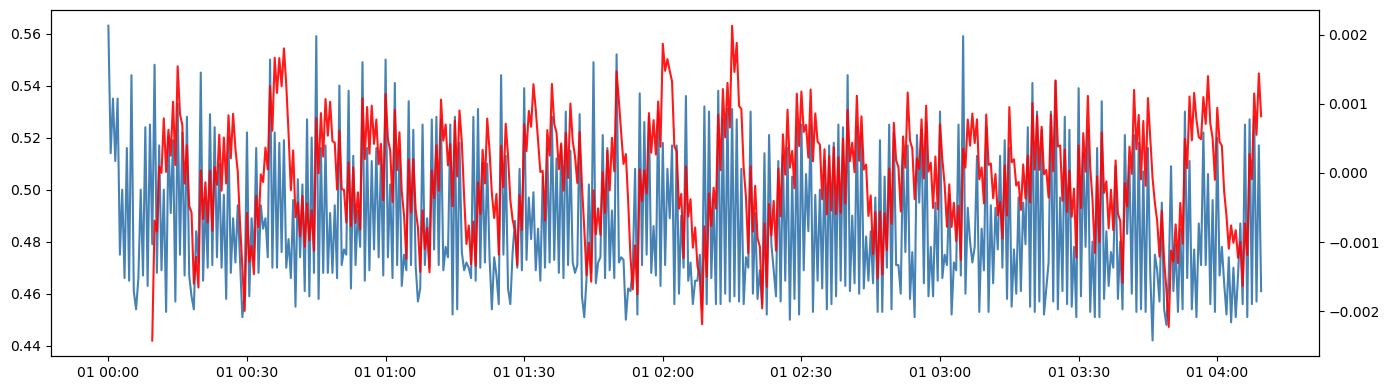

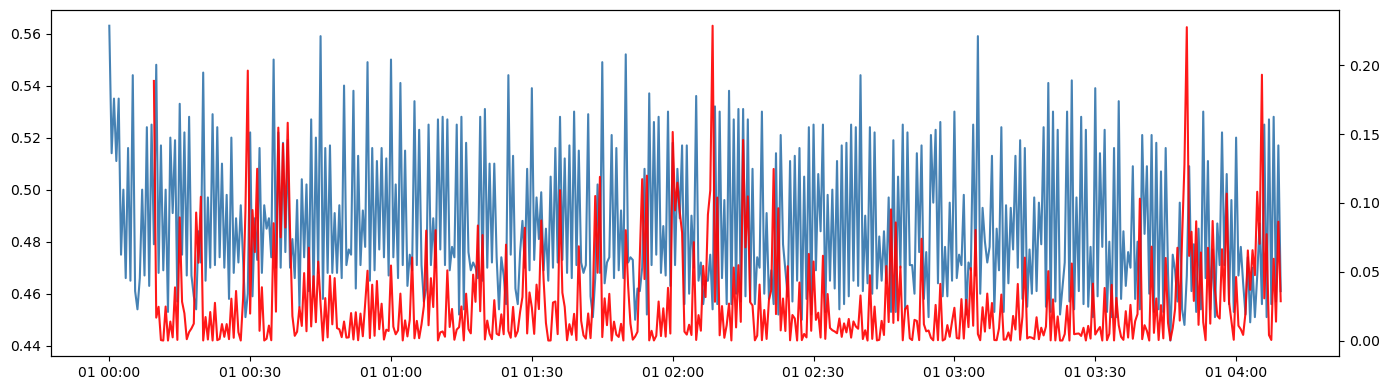

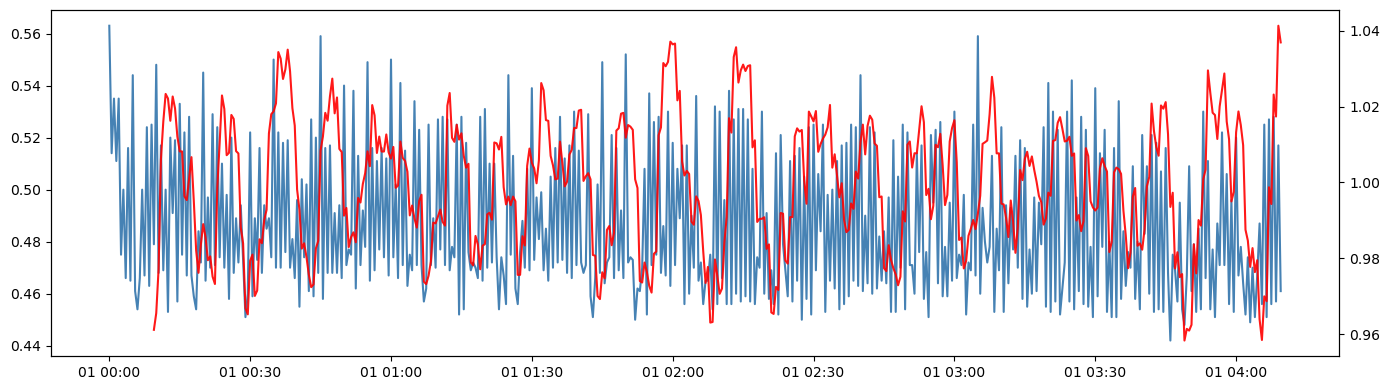

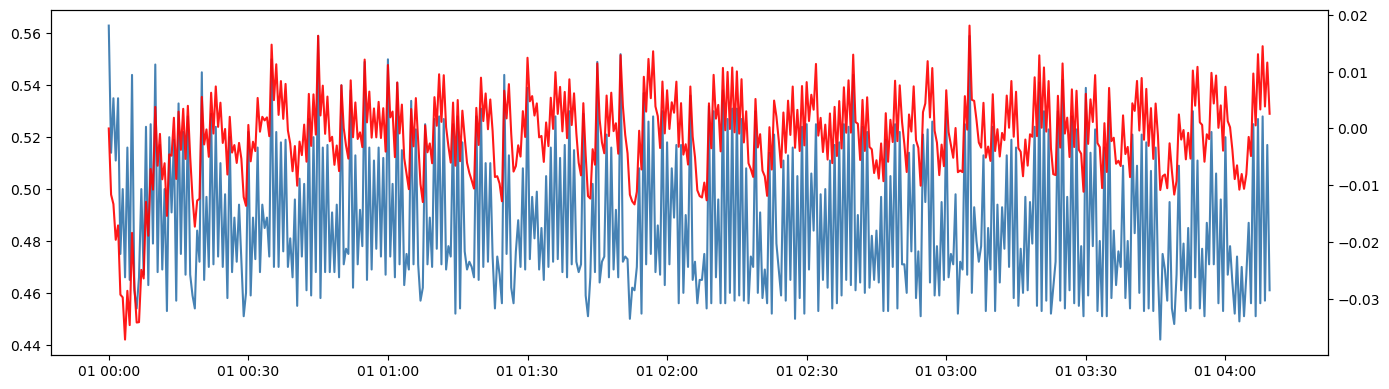

In [38]:
plot_feature(add_trend_slope(data), f'{target}_trend_slope20')
plot_feature(add_trend_slope(data), f'{target}_trend_r220')
plot_feature(add_trend_ratio(data), f'{target}_trend_ratio20')
plot_feature(add_trend_ema_diff(data), f'{target}_trend_ema_diff')

## 6. Comparison table

In [39]:
comp = pd.DataFrame(results).sort_values('RMSE').reset_index(drop=True)
baseline_rmse = comp.loc[comp['variant'] == 'baseline', 'RMSE'].values[0]
comp['pct_change_vs_baseline'] = 100 * (comp['RMSE'] - baseline_rmse) / baseline_rmse
comp

,variant,n_features,MAE,RMSE,MAPE(%),R2,seconds,pct_change_vs_baseline
0,central_variability_calendar,26,0.011970,0.015720,2.458658,0.331815,229.3,-1.396266
1,variability,20,0.012062,0.015846,2.477047,0.321053,137.5,-0.605364
2,kurtosis,18,0.012039,0.015872,2.468014,0.318776,118.7,-0.438851
3,trend_ratio,18,0.012064,0.015898,2.472091,0.316599,123.5,-0.279868
4,central_tendency,19,0.012074,0.015907,2.472544,0.315760,127.3,-0.218702
5,th_aggregated_deltaT,11,0.012097,0.015922,2.479513,0.314487,51.2,-0.125912
6,baseline_minmax_scaler,17,0.012083,0.015928,2.475201,0.313951,102.7,-0.086936
7,roll_calendar,21,0.012078,0.015933,2.473275,0.313539,145.9,-0.056889
8,derivative_stats,22,0.012094,0.015933,2.477289,0.313520,154.5,-0.055543
9,baseline,17,0.012093,0.015942,2.476792,0.312757,99.7,0.000000


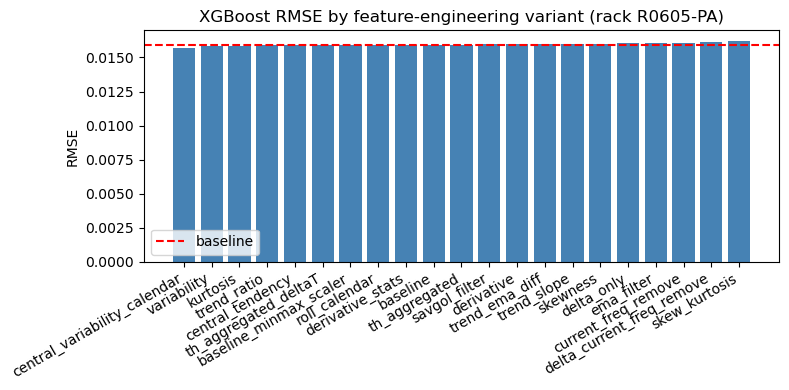

In [40]:
fig, ax = plt.subplots(figsize=(8, 4))
ax.bar(comp['variant'], comp['RMSE'], color='steelblue')
ax.axhline(baseline_rmse, color='red', linestyle='--', label='baseline')
ax.set_ylabel('RMSE')
ax.set_title('XGBoost RMSE by feature-engineering variant (rack R0605-PA)')
plt.xticks(rotation=30, ha='right')
plt.legend()
plt.tight_layout()
plt.show()

## 7. Recommendation

In [41]:
winner = comp.iloc[0]
print(f"Winner: {winner['variant']}  RMSE={winner['RMSE']:.4f}  "
      f"({winner['pct_change_vs_baseline']:+.1f}% vs baseline)")

if winner['variant'].startswith('baseline'):
    print("\n=> No engineered-feature variant beat the raw baseline on this rack/config. "
          "Recommendation: do NOT adopt these features as-is -- the raw sensor set is "
          "already near what XGBoost can extract here.")
else:
    print(f"\n=> Recommend adopting the transformations in '{winner['variant']}' for the "
          "production pipeline, pending confirmation across more racks/models before "
          "promoting into rack_forecast/data.py.")

Winner: central_variability_calendar  RMSE=0.0157  (-1.4% vs baseline)

=> Recommend adopting the transformations in 'central_variability_calendar' for the production pipeline, pending confirmation across more racks/models before promoting into rack_forecast/data.py.


**Scope caveat**: this comparison is single-rack (R0605-PA), single-model, and `train_days=60`-clipped for every variant (including
`baseline`) — not the full 5-month training set `run_03` used. A win here is a
signal worth confirming with a full multi-rack, multi-model, full-data run before
changing the production `build_dataset()` pipeline — not a final verdict.

In [42]:
comp = pd.DataFrame(results).reset_index(drop=True)
baseline_rmse = comp.loc[comp['variant'] == 'baseline', 'RMSE'].values[0]
comp['pct_change_vs_baseline'] = 100 * (comp['RMSE'] - baseline_rmse) / baseline_rmse
comp

,variant,n_features,MAE,RMSE,MAPE(%),R2,seconds,pct_change_vs_baseline
0,baseline,17,0.012093,0.015942,2.476792,0.312757,99.7,0.000000
1,baseline_minmax_scaler,17,0.012083,0.015928,2.475201,0.313951,102.7,-0.086936
2,current_freq_remove,15,0.012399,0.016086,2.559940,0.300266,81.6,0.904710
3,th_aggregated,9,0.012107,0.015948,2.480497,0.312280,37.6,0.034743
4,th_aggregated_deltaT,11,0.012097,0.015922,2.479513,0.314487,51.2,-0.125912
5,delta_only,7,0.012154,0.016042,2.484644,0.304086,23.4,0.628912
6,delta_current_freq_remove,5,0.012481,0.016131,2.579386,0.296396,13.7,1.183355
7,central_tendency,19,0.012074,0.015907,2.472544,0.315760,127.3,-0.218702
8,variability,20,0.012062,0.015846,2.477047,0.321053,137.5,-0.605364
9,roll_calendar,21,0.012078,0.015933,2.473275,0.313539,145.9,-0.056889
